# 02 — Pré-processamento e Baseline (Regressão Logística)

**Objetivo:** transformar os dados brutos + features Pix em algo que um modelo consiga usar (imputar nulos, codificar categóricas, escalonar), dividir os dados de forma realista no tempo, e treinar um primeiro modelo simples (baseline) pra ter um número de referência antes do XGBoost/Random Forest de julho.

Cada etapa tem uma célula de explicação em texto antes do código, pra você acompanhar o raciocínio.

## 1. Carregar dados e adicionar as features Pix

Reaproveita o `data_loader.py` (maio) e o `pix_features.py` (junho) já prontos.

`N_LINHAS` controla quantas transações são lidas. Para **testar** o notebook rápido, use `50_000`. Para a **execução oficial** do entregável de junho, use `None` (as 590.540 transações) — mas atenção: o dataset completo ocupa ~2,2 GB só no DataFrame, e o notebook cria cópias ao dividir treino/val/teste. Em máquina com 8 GB de RAM, feche os outros programas antes de rodar com `None`.

Duas etapas de memória acontecem aqui, e sem elas a execução com o dataset completo não termina em uma máquina de 8 GB:

- **`del dados`** descarta as duas tabelas brutas (`train_transaction` e `train_identity`) assim que a junção e as features estão prontas. Elas somam cerca de 2 GB e não são mais usadas.
- **`reduzir_precisao`** converte as colunas de `float64` para `float32`. Nenhuma coluna do IEEE-CIS precisa de 15 algarismos significativos — `TransactionAmt` não passa de dezenas de milhares. A redução corta ~29% do pico de memória e altera as métricas apenas na quarta casa decimal.

A conversão vem **depois** da engenharia de features, de propósito: `pix_features` calcula janelas móveis que somam valores ao longo de milhares de linhas, e acúmulo é justamente onde a precisão menor pesa.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

RAIZ = Path().resolve().parent
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

from src.data_loader import carregar_dados
from src.features.pix_features import criar_features_pix
from src.features.preprocessor import (
    COLUNA_ALVO,
    construir_preprocessador,
    dividir_temporal,
    identificar_colunas,
    montar_pipeline_modelo,
    reduzir_precisao,
)

# None = dataset completo (execução oficial) | 50_000 = teste rápido
N_LINHAS = None

dados = carregar_dados(nrows=N_LINHAS)
df = criar_features_pix(dados[2])   # dados[2] e o DataFrame ja mesclado
del dados                           # solta as duas tabelas brutas: ~2 GB no dataset completo

df = reduzir_precisao(df)           # float64 -> float32 no caminho da modelagem
print('Shape final (com features Pix):', df.shape)

22:06:29 [INFO] Carregando train_transaction.csv...


22:08:40 [INFO] Carregando train_identity.csv...


22:09:21 [INFO] Dados carregados — transações: (590540, 394) | identidade: (144233, 41)


22:09:21 [INFO] Mesclando DataFrames por TransactionID (left join)...


22:09:31 [INFO] DataFrame final: (590540, 434)


22:09:32 [INFO] Calculando valor_atipico_proxy...


22:09:48 [INFO] Calculando frequencia_recente_proxy...


22:09:58 [INFO] Calculando dispositivo_raro_proxy...


22:10:01 [INFO] Calculando posicao_ciclo_diario_relativa...


22:10:01 [INFO] Features Pix adicionadas: (590540, 440)


22:10:06 [INFO] Precisão reduzida — 2079 MB para 1110 MB (53% do original)


Shape final (com features Pix): (590540, 440)


## 2. Identificar grupos de colunas

Antes de processar, precisamos saber quais colunas são numéricas (viram escala) e quais são categóricas (viram codificação). A função `identificar_colunas` faz isso automaticamente: separa por tipo de dado, já excluindo `TransactionID`/`TransactionDT` (não são features) e `card4`/`card6` (decisão registrada — sem equivalente conceitual em Pix).

In [2]:
numericas, categoricas_baixa, categoricas_alta = identificar_colunas(df)
print('Exemplo de numéricas:', numericas[:5], '...')
print('Categóricas baixa cardinalidade:', categoricas_baixa)
print('Categóricas alta cardinalidade:', categoricas_alta)

22:10:10 [INFO] Colunas identificadas — numéricas: 406 | categóricas baixa cardinalidade: 11 | categóricas alta cardinalidade: 18


Exemplo de numéricas: ['TransactionAmt', 'card1', 'card2', 'card3', 'card5'] ...
Categóricas baixa cardinalidade: ['ProductCD', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'DeviceType']
Categóricas alta cardinalidade: ['P_emaildomain', 'R_emaildomain', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceInfo']


## 3. Split temporal (não aleatório)

Em vez de embaralhar as linhas e separar 70/15/15 aleatoriamente, cortamos por tempo: as transações **mais antigas** viram treino, as **mais recentes** viram teste. Isso é mais realista pra fraude — na vida real você só tem o passado pra prever o futuro, nunca o contrário. Um split aleatório deixaria o modelo "ver" padrões de datas futuras durante o treino, o que infla artificialmente o desempenho.

In [3]:
treino, val, teste = dividir_temporal(df, frac_treino=0.7, frac_val=0.15)

X_treino, y_treino = treino.drop(columns=[COLUNA_ALVO]), treino[COLUNA_ALVO]
X_val, y_val = val.drop(columns=[COLUNA_ALVO]), val[COLUNA_ALVO]
X_teste, y_teste = teste.drop(columns=[COLUNA_ALVO]), teste[COLUNA_ALVO]

print('Taxa de fraude — treino: %.2f%% | val: %.2f%% | teste: %.2f%%' % (
    100 * y_treino.mean(), 100 * y_val.mean(), 100 * y_teste.mean()
))

22:10:16 [INFO] Split temporal — treino: 413378 (70.0%) | val: 88581 (15.0%) | teste: 88581 (15.0%)


Taxa de fraude — treino: 3.52% | val: 3.43% | teste: 3.48%


## 4. Pré-processamento: imputação, codificação e escalonamento

- **Numéricas** → preenche nulo com a **mediana** do treino, depois `StandardScaler` (deixa tudo na mesma escala — importante pra Regressão Logística, que é sensível a magnitude).
- **Categóricas de poucos valores** (`ProductCD`, `DeviceType`, `M1`-`M9`) → preenche nulo com a categoria explícita `"ausente"`, depois vira colunas 0/1 (one-hot).
- **Categóricas de muitos valores** (`P_emaildomain`, `DeviceInfo`, `R_emaildomain`...) → preenche nulo com `"ausente"`, depois vira um número (a frequência daquela categoria no treino) — evita criar centenas de colunas one-hot.

Tudo isso é **ajustado (fit) só com o treino** — validação e teste só usam o que já foi aprendido, nunca ensinam nada ao pré-processador. Essa célula só monta o objeto; ele é usado de verdade dentro do pipeline do modelo, na próxima seção.

> `card1`–`card3` e `card5` são numéricas mascaradas, então caem no grupo das **numéricas** pela regra de dtype de `identificar_colunas` — não neste grupo. `card4` (bandeira) e `card6` (crédito/débito) foram descartadas por decisão registrada: são conceitos exclusivos de cartão, sem equivalente no Pix.

In [4]:
preprocessador = construir_preprocessador(numericas, categoricas_baixa, categoricas_alta)
preprocessador

,transformers,"[('numericas', ...), ('categoricas_baixa', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


### Verificação: o pré-processador faz mesmo o que a tarefa pede?

Esta célula é o **registro de conclusão da tarefa `m2_p1_2`** (imputação de nulos, encoding de categóricas, escalonamento). Ela roda o pré-processador isoladamente numa amostra do treino, só para inspecionar a saída — o ajuste que vale para o modelo acontece dentro do pipeline, na próxima seção.

Três coisas são conferidas:

1. **Imputação** — nenhum nulo sobra na saída, nem no treino nem na validação;
2. **Escalonamento** — as colunas numéricas saem com média ≈ 0 e desvio ≈ 1;
3. **Encoding** — cada coluna da saída carrega o nome real da coluna de origem.

O item 3 não é detalhe cosmético: em julho, o SHAP (`m3_p1_4`) precisa dizer *qual variável* pesou na decisão. Se o codificador de frequência perdesse o nome da coluna, o gráfico do SHAP mostraria `categoricas_alta__7` em vez de `DeviceInfo`, e a Camada 2 da arquitetura aprovada perderia justamente o que ela existe para entregar.

In [5]:
# Amostra só para inspeção — evita duplicar o dataset inteiro na memória.
AMOSTRA_VERIFICACAO = 50_000

pre_verificacao = construir_preprocessador(numericas, categoricas_baixa, categoricas_alta)
X_amostra = X_treino.head(AMOSTRA_VERIFICACAO)

proc_treino = pre_verificacao.fit_transform(X_amostra)          # fit SÓ com treino
proc_val = pre_verificacao.transform(X_val.head(AMOSTRA_VERIFICACAO))  # val só aplica o aprendido
nomes = pre_verificacao.get_feature_names_out()

print('Colunas de entrada:', X_amostra.shape[1], '-> colunas de saída:', len(nomes))
print('1) Nulos restantes  — treino:', int(np.isnan(proc_treino).sum()),
      '| validação:', int(np.isnan(proc_val).sum()))

bloco_numerico = proc_treino[:, :len(numericas)]
print('2) Numéricas no treino — média: %.3f | desvio: %.3f  (esperado ~0 e ~1)' % (
    bloco_numerico.mean(), bloco_numerico.std()))

print('3) Nomes preservados na saída:')
for nome in list(nomes[:2]) + [n for n in nomes if n.startswith('categoricas_alta__')][:3]:
    print('   ', nome)

del proc_treino, proc_val, X_amostra  # libera a memória da inspeção

Colunas de entrada: 439 -> colunas de saída: 459
1) Nulos restantes  — treino: 0 | validação: 0


2) Numéricas no treino — média: 0.000 | desvio: 0.999  (esperado ~0 e ~1)
3) Nomes preservados na saída:
    numericas__TransactionAmt
    numericas__card1
    categoricas_alta__P_emaildomain
    categoricas_alta__R_emaildomain
    categoricas_alta__id_12


## 5. Baseline com ponderação de classe (`class_weight='balanced'`)

Com só 3,5% de fraude, um modelo "preguiçoso" que sempre chuta "não é fraude" já acerta 96,5% — inútil. `class_weight='balanced'` faz o modelo **penalizar mais** quando erra a classe rara (fraude), sem duplicar nenhuma linha de dado.

As métricas vêm de `src/models/evaluator.py`, e não de uma função definida aqui dentro. O motivo é comparabilidade: os modelos de julho (XGBoost e Random Forest) usam o mesmo módulo, então a tabela comparativa final compara números produzidos pelo mesmo código. Duas implementações da mesma métrica são duas chances de divergir em silêncio.

Além das quatro métricas que a tarefa pede, o módulo devolve três que tornam o resultado legível sozinho:

- **precisão** — sem ela o F1 não se interpreta, porque F1 é a média harmônica de precisão e recall;
- **taxa base** (proporção de fraude no conjunto) — a AUC-PR de um classificador aleatório é igual à taxa base, então sem esse número a AUC-PR não tem régua;
- **`auc_pr_relativo`** — quantas vezes a AUC-PR supera esse acaso.

O limiar de decisão é parâmetro explícito (`limiar=0.5`), e não o padrão implícito do `predict`.

In [6]:
from src.models.evaluator import (avaliar, comparar, imprimir, matriz_confusao,
                                  plotar_curva_precisao_recall, resumo_operacional)

pipeline_peso = montar_pipeline_modelo(preprocessador, class_weight='balanced')
pipeline_peso.fit(X_treino, y_treino)

metricas_peso = avaliar(pipeline_peso, X_val, y_val)
imprimir(metricas_peso, 'ponderação de classe (validação)')

--- ponderação de classe (validação) ---
  88.581 transações | 3.042 fraudes | taxa base 3.434% | limiar 0.50
  auc_roc: 0.8410
  auc_pr: 0.3930
  recall: 0.6772
  precisao: 0.1350
  f1: 0.2251
  auc_pr_relativo: 11.4x o acaso


## 6. Baseline com SMOTE

SMOTE cria exemplos sintéticos de fraude (interpolando entre casos reais de fraude do treino) até equilibrar as classes, antes de treinar. É uma estratégia diferente de `class_weight` — por isso comparamos as duas em pipelines separados, nunca misturadas (decisão já registrada nas anotações de metodologia). O SMOTE só é aplicado dentro do treino — nunca em validação/teste, senão estaríamos avaliando em dado inventado.

In [7]:
pipeline_smote = montar_pipeline_modelo(preprocessador, usar_smote=True)
pipeline_smote.fit(X_treino, y_treino)

metricas_smote = avaliar(pipeline_smote, X_val, y_val)
imprimir(metricas_smote, 'SMOTE (validação)')

--- SMOTE (validação) ---
  88.581 transações | 3.042 fraudes | taxa base 3.434% | limiar 0.50
  auc_roc: 0.8391
  auc_pr: 0.3962
  recall: 0.6831
  precisao: 0.1315
  f1: 0.2205
  auc_pr_relativo: 11.5x o acaso


## 7. Comparação

Com desbalanceamento forte, **AUC-PR** é a métrica mais confiável pra comparar (AUC-ROC pode parecer "boa" mesmo quando o modelo erra bastante as fraudes, exatamente por causa dos 96,5% de exemplos fáceis).

In [8]:
comparar({'ponderação de classe': metricas_peso, 'SMOTE': metricas_smote})

,auc_pr,auc_pr_relativo,auc_roc,recall,precisao,f1
ponderação de classe,0.393004,11.444023,0.841005,0.677186,0.135011,0.225137
SMOTE,0.396213,11.537456,0.839084,0.683103,0.131461,0.220489


## 8. Avaliação final no teste

O conjunto de teste só pode ser olhado uma vez, e o critério de escolha precisa ser fixado **antes** — do contrário, escolher a estratégia vendo o resultado do teste transforma o teste em mais um conjunto de validação, e o número deixa de estimar desempenho real.

O critério está registrado em `reports/anotacoes_metodologia.md` desde antes desta execução: as duas estratégias **empataram** na validação, e o desempate se dá por critérios secundários —

1. não fabricar dados sintéticos (o SMOTE cria fraudes que nunca existiram);
2. não interpolar variáveis categóricas já codificadas (o SMOTE gera combinações inexistentes no domínio, como `ProductCD_W = 0,37`);
3. custo computacional, que em julho passa a limitar o que é viável rodar.

Os três apontam para a **ponderação de classe**, que é a estratégia adotada — mesmo quando o SMOTE aparece marginalmente à frente em AUC-PR, porque a diferença é menor que o ruído entre execuções.

O número do SMOTE no teste aparece abaixo por transparência. Ele **não participa da escolha**, que já estava feita.

In [9]:
ESTRATEGIA_ADOTADA = 'ponderação de classe'   # critério declarado; ver seção acima

metricas_teste = avaliar(pipeline_peso, X_teste, y_teste)
imprimir(metricas_teste, f'{ESTRATEGIA_ADOTADA} (TESTE — avaliação final)')

print()
metricas_teste_smote = avaliar(pipeline_smote, X_teste, y_teste)
imprimir(metricas_teste_smote, 'SMOTE (TESTE — reportado, fora da escolha)')

--- ponderação de classe (TESTE — avaliação final) ---
  88.581 transações | 3.083 fraudes | taxa base 3.480% | limiar 0.50
  auc_roc: 0.8286
  auc_pr: 0.1850
  recall: 0.7026
  precisao: 0.1237
  f1: 0.2103
  auc_pr_relativo: 5.3x o acaso



--- SMOTE (TESTE — reportado, fora da escolha) ---
  88.581 transações | 3.083 fraudes | taxa base 3.480% | limiar 0.50
  auc_roc: 0.8238
  auc_pr: 0.1852
  recall: 0.7078
  precisao: 0.1216
  f1: 0.2076
  auc_pr_relativo: 5.3x o acaso


### Matriz de confusão e leitura operacional

As métricas em proporção dizem o quanto o modelo acerta; as contagens absolutas dizem se ele é operável. "Recall de 0,70" e "18 mil transações enviadas para revisão manual" descrevem o mesmo modelo, mas só o segundo número responde se alguém consegue usá-lo.

In [10]:
probas_teste = pipeline_peso.predict_proba(X_teste)[:, 1]

display(matriz_confusao(y_teste, probas_teste))

resumo = resumo_operacional(y_teste, probas_teste)
print(f"Fraudes recuperadas : {resumo['fraudes_recuperadas']:,}".replace(',', '.'))
print(f"Fraudes perdidas    : {resumo['fraudes_perdidas']:,}".replace(',', '.'))
print(f"Transações marcadas : {resumo['transacoes_marcadas']:,}".replace(',', '.'))
print(f"Alarmes falsos      : {resumo['alarmes_falsos']:,}".replace(',', '.'))
print(f"Fração do total marcada: {100 * resumo['fracao_marcada']:.1f}%")

previsto,prevista: legítima,prevista: fraude
observado,,
real: legítima,70151,15347
real: fraude,917,2166


Fraudes recuperadas : 2.166
Fraudes perdidas    : 917
Transações marcadas : 17.513
Alarmes falsos      : 15.347
Fração do total marcada: 19.8%


### Curva de precisão-recall

A linha tracejada é a precisão de um classificador aleatório, que vale a taxa base (~3,5%). Sem ela no gráfico, uma curva ruim em dado desbalanceado parece razoável — é o mesmo motivo pelo qual a acurácia não é reportada em nenhum ponto deste trabalho.

O contraste entre as duas curvas é o achado da seção 9: a mesma configuração, medida em períodos diferentes.

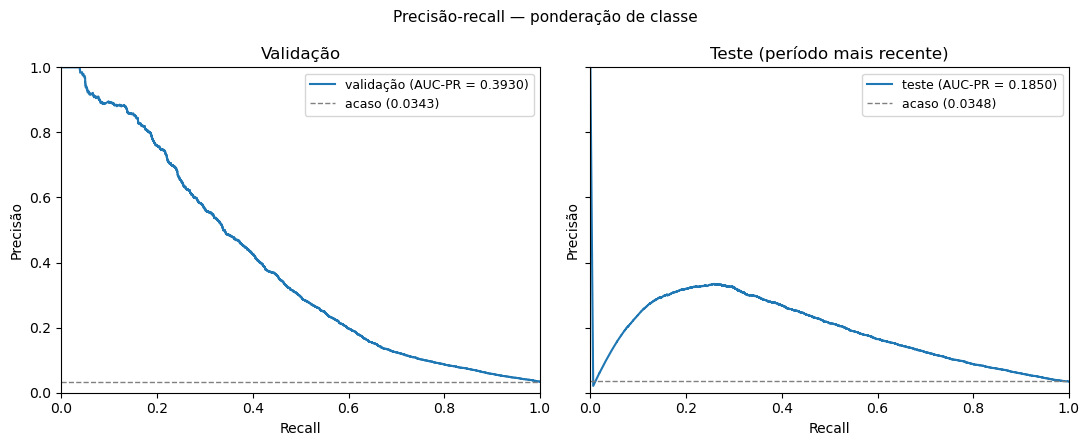

In [11]:
import matplotlib.pyplot as plt

figura, (esq, dir) = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

plotar_curva_precisao_recall(y_val, pipeline_peso.predict_proba(X_val)[:, 1],
                             rotulo='validação', eixo=esq)
esq.set_title('Validação')

plotar_curva_precisao_recall(y_teste, probas_teste, rotulo='teste', eixo=dir)
dir.set_title('Teste (período mais recente)')

figura.suptitle('Precisão-recall — ponderação de classe', fontsize=11)
figura.tight_layout()
plt.show()

## 9. Resultados e próximos passos

### O que este baseline entrega

Sobre as 590.540 transações, com taxa base de 3,434% na validação:

| AUC-PR | Ponderação de classe | SMOTE |
|---|---|---|
| Validação | 0,3930 | 0,3962 |
| Teste | **0,1850** | 0,1852 |

Cerca de **11,4× melhor que o acaso** na validação — a AUC-PR de um classificador aleatório é igual à taxa base.

**As duas estratégias empataram, pela quarta medição consecutiva.** Na amostra de 50.000 linhas a ponderação vencia por 0,006; no dataset completo o SMOTE venceu por 0,003 na validação; no teste a diferença é de 0,0002. Quando o vencedor muda de lado a cada recorte e a margem cabe no ruído entre execuções, não há vencedor. A estratégia adotada é a **ponderação de classe**, pelos critérios declarados na seção 8.

### O achado principal: o desempenho cai no período mais recente

A AUC-PR passa de **0,3930 na validação para 0,1850 no teste** — queda de 52,9% — enquanto:

- as taxas base são praticamente iguais (3,434% e 3,480%), então não é efeito de desbalanceamento;
- a AUC-ROC quase não se move (0,8410 para 0,8286), então o modelo continua ordenando;
- o recall até sobe (0,6772 para 0,7026).

O que se degrada é a **pureza das previsões de maior confiança** no período mais recente, comportamento compatível com envelhecimento dos padrões aprendidos.

Um controle complementar, rodado à parte com o mesmo modelo e os mesmos dados, mediu o contrafactual: sob **divisão aleatória estratificada**, a AUC-PR de teste foi **0,4243** contra **0,1860** do corte temporal no mesmo experimento, e não houve queda alguma entre validação (0,4213) e teste. A divisão aleatória descreveria um modelo estável e 2,3× melhor do que ele é no período recente.

*Ressalva:* a divisão aleatória também coloca transações do mesmo `card1` nos dois lados, então a diferença combina período compartilhado e identificador compartilhado — não se atribui inteiramente ao tempo. Isolar os dois efeitos exigiria um terceiro braço com divisão por grupo, não executado.

### Leitura operacional

Das 3.083 fraudes do período de teste, o modelo recupera **2.166** e perde 917. Para isso marca **17.513 das 88.581 transações** — 19,8% do total — das quais 15.347 são alarme falso. É o comportamento esperado de um baseline linear, e o piso que os modelos de julho precisam superar.

### O que fica pendente

- **O limiar de decisão continua em 0,5**, valor padrão que nunca foi escolhido. Ajustá-lo na validação — nunca no teste — é a melhoria mais barata disponível, e move precisão e recall em direções opostas conforme a prioridade.
- **O SMOTE interpola colunas já codificadas em one-hot**, gerando categorias fracionárias inexistentes no domínio. Limitação assumida, não corrigida.
- **A execução não é reprodutível bit a bit.** O mesmo código com a mesma semente, rodado como script, deu AUC-PR de teste 0,1860 contra 0,1850 aqui. A causa é `float32` somado a operações matriciais paralelas: a ordem das somas varia e o resultado muda nos últimos dígitos. As conclusões não dependem dessa casa, mas números citados devem vir de uma execução identificada.

### O que julho precisa superar

XGBoost (`m3_p1_1`) e Random Forest (`m3_p1_2`) precisam melhorar a **precisão sem perder recall** para justificar a complexidade adicional, e devem ser avaliados no mesmo corte temporal, para que a queda entre validação e teste seja comparável. As métricas virão do mesmo `src/models/evaluator.py` usado aqui. O SHAP (`m3_p1_4`) então explica quais variáveis pesaram nessas decisões.